# 04 Deep dive: robustness, interactions, drift and uncertainty

Four questions that go beyond "the model works":

1. **Robustness of drivers:** do age, team strength and league stay on top with other importance methods, and
   with a different model (Ridge)? How do correlated features distort single-feature rankings?
2. **Interactions:** are effects additive, or does e.g. the value of playing time depend on age?
3. **Drift between seasons:** what changed from 2024/25 to 2025/26, and why does the model under-predict the
   test season on average?
4. **Uncertainty:** how wide is a realistic prediction interval per player, and which players lie outside it?

Methods are adapted from the course notebooks on tree-based feature importance, SHAP and drift analysis.
All diagnostics use the LightGBM model trained on 2024/25; unless stated otherwise they are computed on the
test season 2025/26. Helper functions live in `src/diagnostics.py`.

## 0. Setup

In [1]:
import itertools
import os
import sys
from pathlib import Path

# joblib counts CPU cores via `wmic`, which Windows 11 no longer ships (noisy warning).
# Setting a limit below the logical core count skips that lookup.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) - 1)))

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.inspection import permutation_importance

from src import config
from src.diagnostics import FEATURE_GROUPS, drift_table, grouped_permutation_importance, h_statistic, partial_dependence
from src.train_models import load_data
from src.value_gap import compute_gaps

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
# Categorical palette in fixed order (series 1-5); gap colours as in notebook 03
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
GAP_COLORS = {"Above": "#1c5cab", "Within": "#b5b3ad", "Below": "#e34948"}
BASE_COLOR = SERIES[0]
LABEL = config.FEATURE_LABELS

def save(fig, name):
    """Save a figure to reports/figures for later use in the README."""
    config.FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(config.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df = load_data()
FEATURES = config.NUMERIC_FEATURES + config.CATEGORICAL_FEATURES
train = df[df["season"] == config.TRAIN_SEASON].reset_index(drop=True)
test = df[df["season"] == config.TEST_SEASON].reset_index(drop=True)
X_test, y_test = test[FEATURES], test[config.TARGET]

lgbm = joblib.load(config.MODELS_DIR / "lightgbm.joblib")
ridge = joblib.load(config.MODELS_DIR / "ridge.joblib")
gaps = compute_gaps(df, pd.read_parquet(config.PREDICTIONS_PATH))
print(f"Train {len(train):,} | test {len(test):,} players")

Train 1,391 | test 1,482 players


## 1. Robustness of the drivers

### 1.1 Four importance methods side by side
- **Gain** (LightGBM built-in): how much a feature reduced the training error. Known to favour features with many
  split points.
- **Permutation importance**: how much the test error (RMSE) rises when one feature is shuffled. Model-agnostic,
  measured on unseen data.
- **Mean |SHAP|**: average absolute contribution to the predictions (notebook 03).
- **Ridge permutation importance**: same idea, but for the linear model. If both models agree, the driver is not
  an artefact of one algorithm.

Each method is scaled to shares that sum to 100%, so they are comparable.

In [3]:
perm_lgbm = permutation_importance(lgbm, X_test, y_test, n_repeats=10, random_state=config.RANDOM_STATE,
                                   scoring="neg_root_mean_squared_error")
perm_ridge = permutation_importance(ridge, X_test, y_test, n_repeats=10, random_state=config.RANDOM_STATE,
                                    scoring="neg_root_mean_squared_error")
gain = pd.Series(lgbm.booster_.feature_importance("gain"), index=lgbm.booster_.feature_name())
mean_shap = pd.Series(np.abs(shap.TreeExplainer(lgbm)(X_test).values).mean(axis=0), index=FEATURES)

methods = pd.DataFrame({
    "LightGBM gain": gain,
    "LightGBM permutation": pd.Series(perm_lgbm.importances_mean, index=FEATURES).clip(lower=0),
    "LightGBM mean |SHAP|": mean_shap,
    "Ridge permutation": pd.Series(perm_ridge.importances_mean, index=FEATURES).clip(lower=0),
}).loc[FEATURES]
shares = methods / methods.sum()
shares.index = shares.index.map(LABEL)
top = shares.mean(axis=1).sort_values(ascending=False).index[:12]
shares.loc[top].style.format("{:.1%}")

,LightGBM gain,LightGBM permutation,LightGBM mean |SHAP|,Ridge permutation
Age,28.8%,44.6%,22.6%,40.9%
League,8.9%,17.3%,12.3%,18.1%
Team goal difference per game,25.8%,10.6%,14.1%,2.8%
Team points per game,8.7%,4.5%,6.2%,7.8%
League minutes,4.6%,6.8%,7.8%,7.1%
Champions League minutes,5.2%,4.2%,5.2%,5.7%
League appearances,1.1%,2.6%,3.8%,6.4%
Goals,4.2%,2.5%,4.6%,0.1%
Previous season minutes,2.9%,1.5%,4.9%,0.7%
Share of league minutes,1.6%,0.9%,3.1%,3.4%


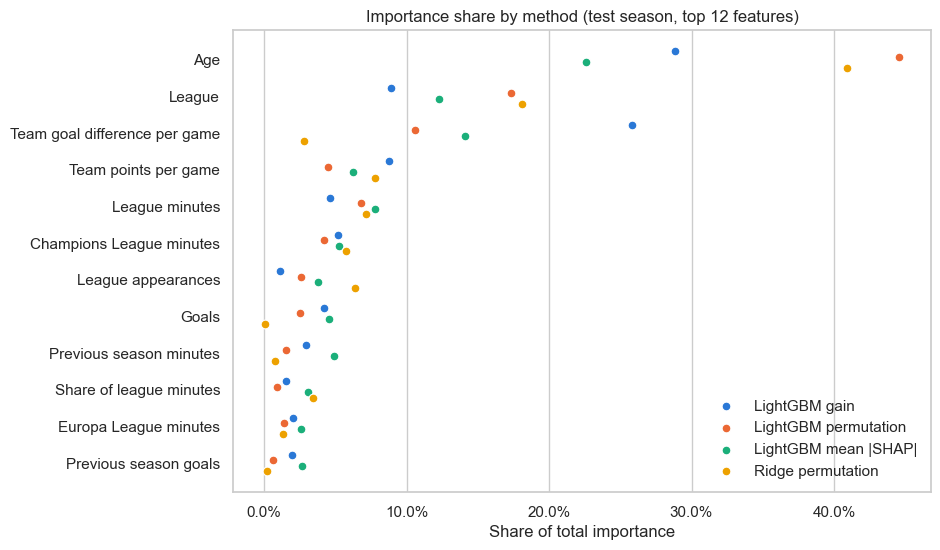

,LightGBM gain,LightGBM permutation,LightGBM mean |SHAP|,Ridge permutation
LightGBM gain,1.00,0.93,0.96,0.78
LightGBM permutation,0.93,1.00,0.96,0.81
LightGBM mean |SHAP|,0.96,0.96,1.00,0.81
Ridge permutation,0.78,0.81,0.81,1.00


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(top))[::-1]
for i, (method, color) in enumerate(zip(shares.columns, SERIES)):
    ax.scatter(shares.loc[top, method], y + (1.5 - i) * 0.15, s=40, color=color, label=method, zorder=3,
               edgecolors="white", linewidths=0.8)
ax.set_yticks(y, top)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
ax.set(title="Importance share by method (test season, top 12 features)", xlabel="Share of total importance")
save(fig, "17_importance_methods")
plt.show()

# How similar are the rankings? Spearman rank correlation between methods
shares.rank(ascending=False).corr(method="spearman").style.format("{:.2f}")

### 1.2 Correlated features split the credit
Goals and goals per 90, or points per game and goal difference, carry similar information. Single-feature
methods then spread the importance between them, so each looks smaller than the concept really is. The
dendrogram clusters numeric features by Spearman correlation: features that merge close to 0 are near-duplicates.

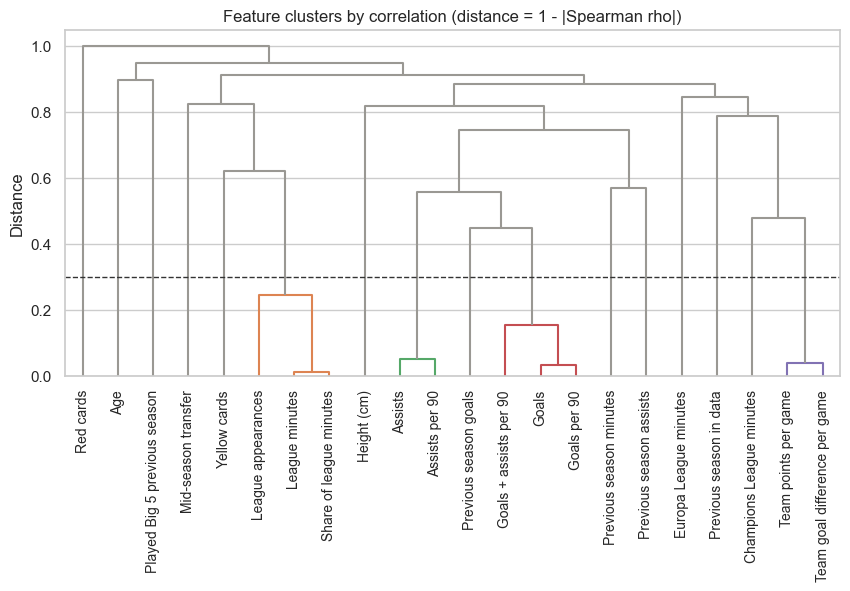

In [5]:
num = config.NUMERIC_FEATURES
corr = test[num].corr(method="spearman").fillna(0).to_numpy()
np.fill_diagonal(corr, 1)
dist = squareform(1 - np.abs(corr), checks=False)
link = hierarchy.linkage(dist, method="average")

fig, ax = plt.subplots(figsize=(10, 4.5))
hierarchy.dendrogram(link, labels=[LABEL[f] for f in num], leaf_rotation=90, ax=ax,
                     color_threshold=0.3, above_threshold_color="#9a9893")
ax.axhline(0.3, color="#333333", linestyle="--", linewidth=1)
ax.set(title="Feature clusters by correlation (distance = 1 - |Spearman rho|)", ylabel="Distance")
ax.grid(axis="x", visible=False)
save(fig, "18_feature_clusters")
plt.show()

### 1.3 Grouped permutation importance: importance by business concept
All features of a concept are shuffled together, which solves the credit-splitting problem above. Run for both
models: if LightGBM and Ridge agree on the order, the conclusion does not depend on the algorithm.

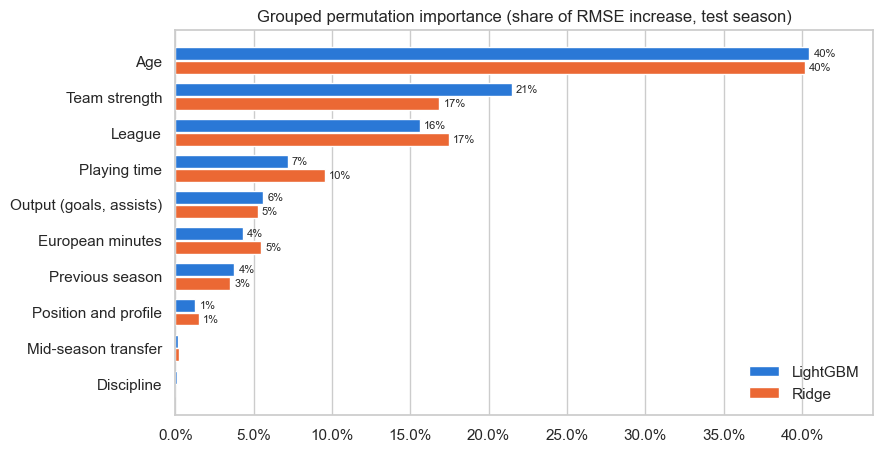

,LightGBM,Ridge
group,,
Age,40.5%,40.2%
Team strength,21.5%,16.9%
League,15.6%,17.4%
Playing time,7.2%,9.6%
"Output (goals, assists)",5.6%,5.3%
European minutes,4.3%,5.5%
Previous season,3.8%,3.5%
Position and profile,1.3%,1.5%
Mid-season transfer,0.2%,0.2%


In [6]:
grouped = {}
for name, model in [("LightGBM", lgbm), ("Ridge", ridge)]:
    g = grouped_permutation_importance(model, X_test, y_test, FEATURE_GROUPS, n_repeats=10,
                                       random_state=config.RANDOM_STATE).set_index("group")
    grouped[name] = (g["rmse_increase"].clip(lower=0) / g["rmse_increase"].clip(lower=0).sum())
grouped = pd.DataFrame(grouped).sort_values("LightGBM")

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(grouped))
for i, (name, color) in enumerate(zip(grouped.columns, SERIES)):
    bars = ax.barh(y + (0.5 - i) * 0.38, grouped[name], height=0.36, color=color, label=name)
    ax.bar_label(bars, labels=[f"{v:.0%}" if v >= 0.01 else "" for v in grouped[name]], padding=3, fontsize=8)
ax.set_yticks(y, grouped.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.margins(x=0.1)
ax.legend(frameon=False, loc="lower right")
ax.set(title="Grouped permutation importance (share of RMSE increase, test season)")
save(fig, "19_grouped_importance")
plt.show()
grouped.sort_values("LightGBM", ascending=False).style.format("{:.1%}")

## 2. Interactions

### 2.1 How strong are interactions? (Friedman's H-statistic)
For a pair of features, H measures which share of their joint effect cannot be explained by adding up their
individual effects. 0 = purely additive, 1 = pure interaction. Values below about 0.1 are weak.
*Note: SHAP interaction values were tested but do not add up correctly for LightGBM's categorical splits
(max error 0.096), so this model-agnostic measure is used instead.*

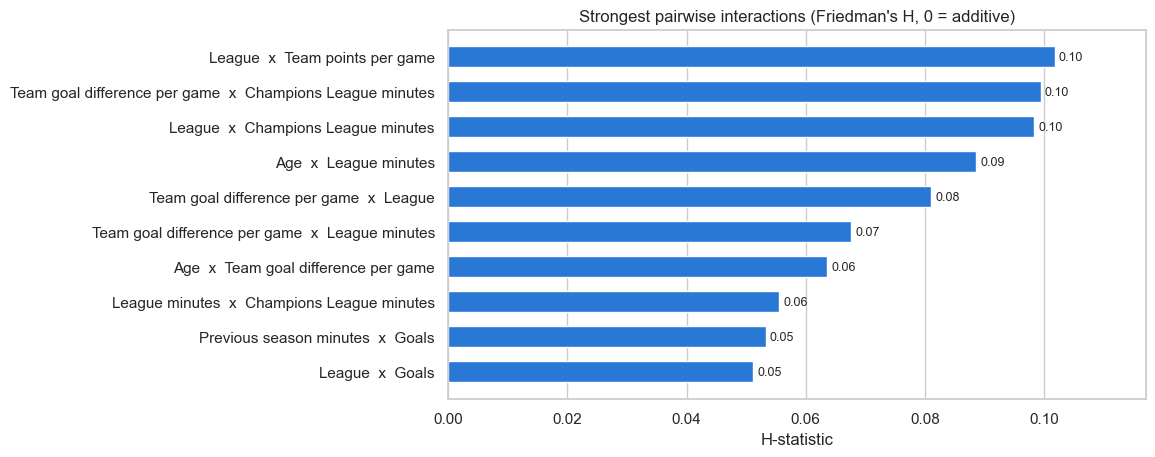

Median H across 28 pairs: 0.046, max: 0.102


In [7]:
TOP_FEATURES = ["age", "team_goal_diff_pg", "league", "minutes", "team_ppg", "cl_minutes", "prev_minutes", "goals"]
h = h_statistic(lgbm, X_test, list(itertools.combinations(TOP_FEATURES, 2)), n_sample=250,
                random_state=config.RANDOM_STATE)
h["pair"] = h["feature_a"].map(LABEL) + "  x  " + h["feature_b"].map(LABEL)

top_h = h.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(top_h["pair"], top_h["h_statistic"], color=BASE_COLOR, height=0.6)
ax.bar_label(bars, labels=[f"{v:.2f}" for v in top_h["h_statistic"]], padding=3, fontsize=9)
ax.grid(axis="y", visible=False)
ax.margins(x=0.15)
ax.set(title="Strongest pairwise interactions (Friedman's H, 0 = additive)", xlabel="H-statistic")
save(fig, "20_interactions_h")
plt.show()
print(f"Median H across {len(h)} pairs: {h['h_statistic'].median():.3f}, max: {h['h_statistic'].max():.3f}")

### 2.2 Two-way partial dependence
Predicted market value when every player is assigned the same pair of values (all other features unchanged),
averaged over all players. Left: age x team strength. Right: the age curve per league.

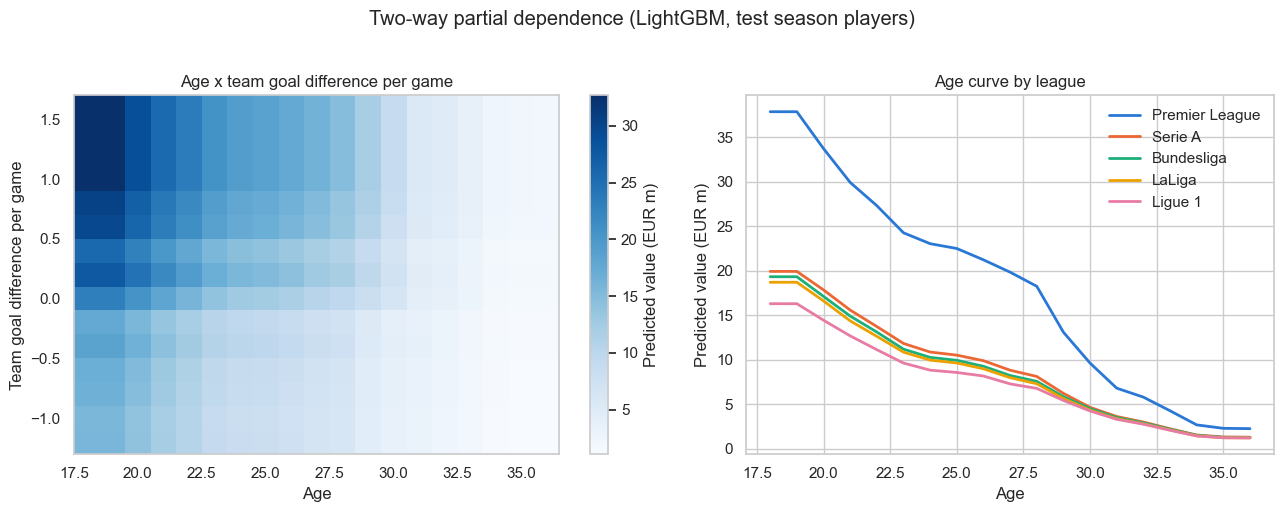

,Premier League premium vs other leagues
18,+104%
21,+108%
24,+131%
27,+146%
30,+118%
33,+99%
36,+82%


In [8]:
ages = np.arange(18, 37)
gds = np.round(np.arange(-1.2, 1.61, 0.2), 1)
grid = pd.DataFrame(list(itertools.product(ages, gds)), columns=["age", "team_goal_diff_pg"])
pd_age_gd = np.exp(partial_dependence(lgbm, X_test, ["age", "team_goal_diff_pg"], grid)).reshape(len(ages), len(gds)) / 1e6

leagues = list(X_test["league"].cat.categories)
grid_l = pd.DataFrame(list(itertools.product(ages, leagues)), columns=["age", "league"])
pd_age_league = pd.DataFrame(
    np.exp(partial_dependence(lgbm, X_test, ["age", "league"], grid_l)).reshape(len(ages), len(leagues)) / 1e6,
    index=ages, columns=[config.TOP5_LEAGUES[l] for l in leagues])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.15, 1]})
im = axes[0].imshow(pd_age_gd.T, origin="lower", aspect="auto", cmap="Blues",
                    extent=[ages[0] - 0.5, ages[-1] + 0.5, gds[0] - 0.1, gds[-1] + 0.1])
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Predicted value (EUR m)")
axes[0].set(title="Age x team goal difference per game", xlabel="Age", ylabel="Team goal difference per game")
axes[0].grid(False)

order = pd_age_league.loc[24].sort_values(ascending=False).index
for name, color in zip(order, SERIES):
    axes[1].plot(ages, pd_age_league[name], color=color, linewidth=2, label=name)
axes[1].set(title="Age curve by league", xlabel="Age", ylabel="Predicted value (EUR m)")
axes[1].legend(frameon=False)
fig.suptitle("Two-way partial dependence (LightGBM, test season players)", y=1.02)
fig.tight_layout()
save(fig, "21_partial_dependence_2d")
plt.show()

# Premium of the Premier League over the other leagues, by age
prem = pd_age_league["Premier League"] / pd_age_league.drop(columns="Premier League").mean(axis=1) - 1
prem.loc[[18, 21, 24, 27, 30, 33, 36]].to_frame("Premier League premium vs other leagues").style.format("{:+.0%}")

## 3. Drift between 2024/25 and 2025/26

### 3.1 Did the inputs change?
**Population stability index (PSI)** compares the distribution of each feature in the test season with the train
season (rule of thumb: < 0.10 stable, 0.10-0.25 moderate, > 0.25 major). The **KS test** checks whether two samples
come from the same distribution (small p-value = different).

In [9]:
drift = drift_table(train, test, FEATURES + [config.TARGET])
drift["feature"] = drift["feature"].map({**LABEL, config.TARGET: "log(market value) [target]"})
drift.head(12).style.format({"psi": "{:.3f}", "ks_stat": "{:.3f}", "ks_pvalue": "{:.3f}",
                             "median_ref": "{:,.2f}", "median_cur": "{:,.2f}"}, na_rep="")

,feature,psi,ks_stat,ks_pvalue,median_ref,median_cur,psi_level
0,Team points per game,0.131,0.125,0.000,1.37,1.29,moderate
1,Team goal difference per game,0.100,0.096,0.000,-0.03,-0.11,moderate
2,Red cards,0.034,0.101,0.000,0.00,0.00,stable
3,Goals + assists per 90,0.020,0.034,0.380,0.18,0.18,stable
4,Yellow cards,0.020,0.062,0.007,4.00,3.00,stable
5,Previous season minutes,0.018,0.029,0.685,"1,779.00","1,789.50",stable
6,Assists,0.018,0.043,0.137,2.00,2.00,stable
7,Assists per 90,0.016,0.038,0.256,0.09,0.08,stable
8,log(market value) [target],0.015,0.034,0.384,16.12,16.12,stable
9,League minutes,0.012,0.050,0.056,"1,910.00","1,844.50",stable


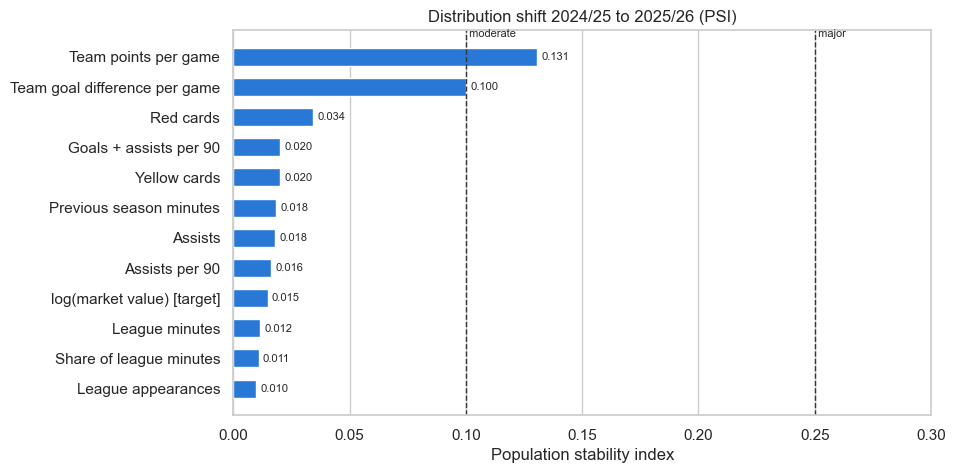

In [10]:
top_d = drift.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_d["feature"], top_d["psi"], color=BASE_COLOR, height=0.6)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in top_d["psi"]], padding=3, fontsize=8)
for x, label in [(0.10, "moderate"), (0.25, "major")]:
    ax.axvline(x, color="#333333", linestyle="--", linewidth=1)
    ax.text(x, len(top_d) - 0.4, f" {label}", fontsize=8, va="bottom")
ax.grid(axis="y", visible=False)
ax.set(title=f"Distribution shift {config.season_label(config.TRAIN_SEASON)} to {config.season_label(config.TEST_SEASON)} (PSI)",
       xlabel="Population stability index", xlim=(0, 0.3))
save(fig, "22_drift_psi")
plt.show()

### 3.2 Why does the model under-predict 2025/26 by about 14% on average?
The mean gap in the test season can be split exactly into two parts:
**mean gap = (mean actual log value, test - train) - (mean predicted log value, test - train)**, because the
mean gap in the train season is 0 by construction (out-of-fold). SHAP then shows which features move the
predictions.

In [11]:
p = pd.read_parquet(config.PREDICTIONS_PATH)
level = p.groupby("season")[[config.TARGET, "pred_log_lightgbm"]].mean()
d_actual = level.loc[config.TEST_SEASON, config.TARGET] - level.loc[config.TRAIN_SEASON, config.TARGET]
d_pred = level.loc[config.TEST_SEASON, "pred_log_lightgbm"] - level.loc[config.TRAIN_SEASON, "pred_log_lightgbm"]
gap_test = (p.loc[p["season"] == config.TEST_SEASON, config.TARGET]
            - p.loc[p["season"] == config.TEST_SEASON, "pred_log_lightgbm"]).mean()

decomp = pd.DataFrame({"log units": [d_actual, -d_pred, gap_test]},
                      index=["Actual values higher (level)", "Predictions lower (features)", "Mean gap test season"])
decomp["as % of value"] = np.exp(decomp["log units"]) - 1
display(decomp.style.format({"log units": "{:+.3f}", "as % of value": "{:+.1%}"}))

# Which features lower the predictions? Mean SHAP per feature with the same (refit) model in both seasons
explainer = shap.TreeExplainer(lgbm)
mean_shap_season = {s: pd.Series(explainer(g[FEATURES]).values.mean(axis=0), index=FEATURES)
                    for s, g in df.groupby("season")}
shift = (mean_shap_season[config.TEST_SEASON] - mean_shap_season[config.TRAIN_SEASON]).rename(index=LABEL)
shift.sort_values().head(6).to_frame("change in mean SHAP (log)").style.format("{:+.3f}")

,log units,as % of value
Actual values higher (level),+0.071,+7.3%
Predictions lower (features),+0.065,+6.8%
Mean gap test season,+0.136,+14.6%


,change in mean SHAP (log)
Team goal difference per game,-0.045
League minutes,-0.013
Share of league minutes,-0.005
Age,-0.004
Goals,-0.004
Champions League minutes,-0.004


In [12]:
# Same players in both seasons: how did the market and the model see them one year later?
wide = p.pivot_table(index="player_id", columns="season", values=[config.TARGET, "pred_log_lightgbm"]).dropna()
d_mkt = wide[config.TARGET][config.TEST_SEASON] - wide[config.TARGET][config.TRAIN_SEASON]
d_mod = wide["pred_log_lightgbm"][config.TEST_SEASON] - wide["pred_log_lightgbm"][config.TRAIN_SEASON]
print(f"{len(wide):,} players in both seasons")
print(f"Market value change: median {np.exp(d_mkt.median()) - 1:+.1%}, mean {np.exp(d_mkt.mean()) - 1:+.1%}")
print(f"Model prediction change: median {np.exp(d_mod.median()) - 1:+.1%}, mean {np.exp(d_mod.mean()) - 1:+.1%}")

940 players in both seasons
Market value change: median -10.0%, mean -3.6%
Model prediction change: median -14.8%, mean -11.5%


## 4. Prediction intervals: how certain is a single prediction?

### 4.1 Calibration of the 80% interval
Two quantile models (10% and 90%) give a raw band per player. Raw quantile models are usually too narrow, so the
band is widened by a constant learned from the train season's out-of-fold errors (**conformalized quantile
regression**, CQR). The test season is the honest check: about 80% of players should fall inside.

In [13]:
from src.value_gap import conformal_margin

def coverage_row(g, lo, hi):
    inside = (g[config.TARGET] >= lo) & (g[config.TARGET] <= hi)
    return {"coverage": inside.mean(), "above": (g[config.TARGET] > hi).mean(), "below": (g[config.TARGET] < lo).mean()}

is_train = gaps["season"] == config.TRAIN_SEASON
margin = conformal_margin(gaps.loc[is_train, config.TARGET], gaps.loc[is_train, "pred_log_q_lo"],
                          gaps.loc[is_train, "pred_log_q_hi"], config.INTERVAL_COVERAGE)
shift_s = gaps.groupby("season")["gap_log"].transform("median")
rows = []
for label, g in gaps.groupby("season_label"):
    rows.append({"season": label, "interval": "raw quantiles", **coverage_row(g, g["pred_log_q_lo"], g["pred_log_q_hi"])})
    rows.append({"season": label, "interval": "CQR", **coverage_row(g, g["interval_log_lo"], g["interval_log_hi"])})
    s = shift_s.loc[g.index]
    rows.append({"season": label, "interval": "CQR, season-centred", **coverage_row(g, g["interval_log_lo"] + s, g["interval_log_hi"] + s)})
print(f"Conformal margin: {margin:.3f} log units on each side")
pd.DataFrame(rows).set_index(["season", "interval"]).style.format("{:.1%}")

Conformal margin: 0.154 log units on each side


### 4.2 How wide is the interval, and for whom?
Width as a factor: upper bound divided by lower bound. A factor of 3 means e.g. EUR 5m to EUR 15m.

In [14]:
gaps["width_factor"] = np.exp(gaps["interval_log_hi"] - gaps["interval_log_lo"])
gaps["age_group"] = pd.cut(gaps["age"], bins=config.AGE_BINS, labels=config.AGE_LABELS, right=False)
t = gaps[gaps["season"] == config.TEST_SEASON]
print(f"Median width factor (test season): {t['width_factor'].median():.1f}x "
      f"(10th pct {t['width_factor'].quantile(0.1):.1f}x, 90th pct {t['width_factor'].quantile(0.9):.1f}x)")
t.groupby("age_group", observed=True)["width_factor"].median().to_frame("median width factor").style.format("{:.1f}x")

Median width factor (test season): 3.8x (10th pct 2.5x, 90th pct 6.0x)


,median width factor
age_group,
<21,4.2x
21-23,3.9x
24-26,3.7x
27-29,3.5x
30+,4.0x


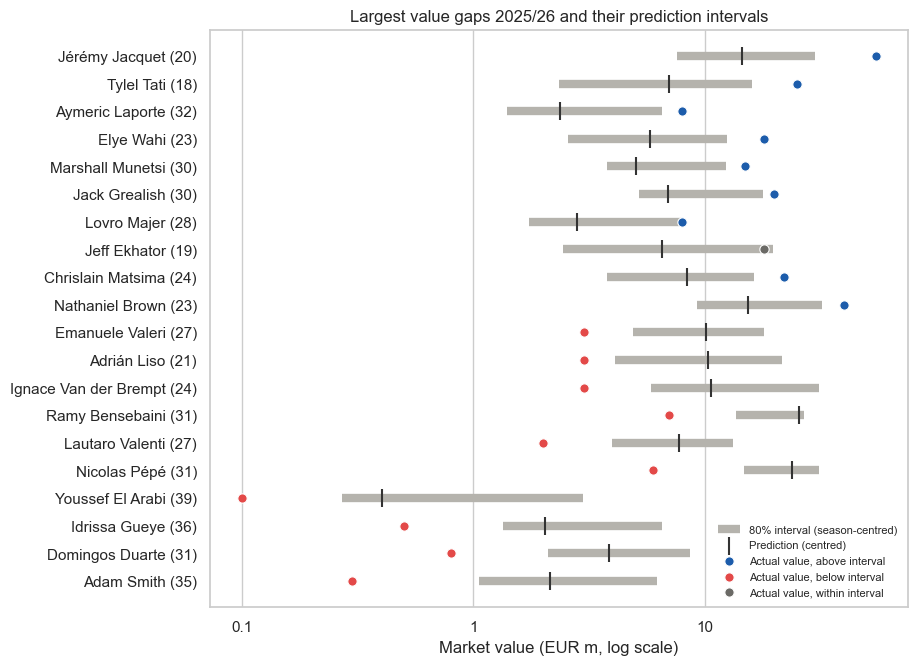

In [15]:
# The 10 largest positive and negative gaps of the test season with their intervals
show = pd.concat([t.nlargest(10, "gap_log_centred"), t.nsmallest(10, "gap_log_centred")]).sort_values("gap_log_centred")
fig, ax = plt.subplots(figsize=(9, 7.5))
yy = np.arange(len(show))
ax.hlines(yy, show["value_lower"] / 1e6, show["value_upper"] / 1e6, color=GAP_COLORS["Within"], linewidth=6,
          label="80% interval (season-centred)")
ax.scatter(np.exp(show["pred_log_lightgbm"] + shift_s.loc[show.index]) / 1e6, yy, marker="|", s=180,
           color="#333333", label="Prediction (centred)", zorder=3)
for flag, color in [("Above interval", GAP_COLORS["Above"]), ("Below interval", GAP_COLORS["Below"]),
                    ("Within interval", "#6b6a66")]:
    m = (show["interval_flag"] == flag).to_numpy()
    ax.scatter(show["market_value"].to_numpy()[m] / 1e6, yy[m], s=45, color=color, zorder=4, edgecolors="white",
               linewidths=0.8, label=f"Actual value, {flag.lower()}")
ax.set_yticks(yy, show["name"] + " (" + show["age"].round().astype(int).astype(str) + ")")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set(xlabel="Market value (EUR m, log scale)",
       title=f"Largest value gaps {config.season_label(config.TEST_SEASON)} and their prediction intervals")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right", fontsize=8)
save(fig, "23_prediction_intervals")
plt.show()

### 4.3 Two ways to flag a player
*Top/bottom 10%* ranks players by the size of their gap. *Outside the interval* also takes into account how
uncertain the prediction is: the same +80% gap can be normal for a hard-to-predict 19-year-old and unusual for an
established 27-year-old.

In [16]:
pd.crosstab([gaps["season_label"], gaps["gap_category"]], gaps["interval_flag"], margins=True)

interval_flag              Above interval  Below interval  Within interval  \
season_label gap_category                                                    
2024/25      Above model               77               0               63   
             Below model                0              88               51   
             In line                   63              52              997   
2025/26      Above model               65               0               84   
             Below model                0              99               49   
             In line                   47              49             1089   
All                                   252             288             2333   

interval_flag               All  
season_label gap_category        
2024/25      Above model    140  
             Below model    139  
             In line       1112  
2025/26      Above model    149  
             Below model    148  
             In line       1185  
All                        2873

## 5. Findings
*Numbers from the run on 2026-10-01.*

**1. The drivers are robust.**
- Age ranks first with every method (23-45% of importance) and for both models.
- Grouped by concept, LightGBM and Ridge agree closely: **age 40%**, **team strength 17-22%**, **league 16-17%**,
  playing time 7-10%, goals and assists 5-6%, European minutes 4-6%, previous season 3-4%, position and profile
  about 1%. Rankings of the three LightGBM methods correlate at 0.93-0.96, with Ridge at 0.78-0.81.
- Single-feature rankings are misleading for correlated features: Ridge gives team goal difference only 3%, but
  the team-strength concept 17%, because points per game carries the same information.

**2. Effects are mostly additive.**
- Interactions are weak (median H = 0.05, max 0.10 for league x points per game). This explains why the linear
  Ridge model is almost as accurate as LightGBM.
- The Premier League premium over the other four leagues is large at every age (+82% to +146%) and peaks around
  age 27 (+146%).

**3. The test-season gap is half price level, half feature drift.**
- Inputs are stable (PSI < 0.05) except team strength (points per game PSI 0.13, goal difference 0.10): the
  2025/26 sample contains more players from teams with a negative goal difference (median team points per game
  1.37 to 1.29), while league-wide averages hardly changed.
- The mean gap of +14.6% in 2025/26 splits into **+7.3% higher actual values** and **+6.8% lower predictions**,
  mostly from the shift in team goal difference (-0.045 log). It is therefore not pure market inflation.
- For the 940 players in both seasons, the market lowered values by 10% (median) while the model expected -15%:
  the market depreciates a player who is one year older less than the cross-section suggests.

**4. Single predictions are uncertain; intervals make the gap list more honest.**
- Raw quantile models cover only 66-68% instead of 80%; after conformal calibration coverage is **80.1% (train)
  and 80.8% (test)**, i.e. the method is valid out of sample.
- The median 80% interval spans a factor of **3.8** (e.g. EUR 5m to EUR 19m), widest for under-21s (4.2x) and
  over-30s (4.0x). A point prediction alone overstates precision.
- Only 44% of the 2025/26 *Above model* players are also above their interval; 47 *In line* players are. The
  interval flag accounts for player-specific uncertainty and is the stricter criterion for the scouting list.

**Implications for the dashboard (day 5):** show the interval next to each prediction, offer both flags, and state
that the season-level shift is partly feature drift, not only market inflation.